In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import rna_utils as ru

DATA_PATH    = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/"

DIST_PATH    = DATA_PATH + "rnadist_f_all.h5"
dist100_PATH = DATA_PATH + "rnadist_filtered100.h5"
dist200_PATH = DATA_PATH + "rnadist_filtered200.h5"
dist400_PATH = DATA_PATH + "rnadist_filtered400.h5"
META_PATH    = DATA_PATH + "sources/ArchiveII_with_prob_and_motiv.csv"

In [3]:
dist, meta = ru.load_and_align(corr_path=DIST_PATH, meta_path=META_PATH)
dist100, meta100 = ru.load_and_align(corr_path=dist100_PATH, meta_path=META_PATH)
dist200, meta200 = ru.load_and_align(corr_path=dist200_PATH, meta_path=META_PATH)
dist400, meta400 = ru.load_and_align(corr_path=dist400_PATH, meta_path=META_PATH)

print(meta400.groupby("fam")["sequence"].count())

fam
16s            66
23s            15
5s            400
RNaseP        400
grp1           74
srp           400
tRNA          400
telomerase     35
tmRNA         400
Name: sequence, dtype: int64


In [4]:

def get_min_mean(fam):
    min_dists = ru.table_min_inter_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def get_avg_min_mean(fam):
    min_dists = ru.table_avg_min_intra_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def make_long_df(df, value_name="Distancia"):
    df_long = df.reset_index().melt(
        id_vars="index", var_name="Familia", value_name=value_name
    )
    df_long.rename(columns={"index": "Condición"}, inplace=True)
    return df_long


def reorder_df_by_diagonal(df, fixed_order=True):
    fixed_labels = [
    "telomerase",
    "5s",
    "tRNA",
    "tmRNA",
    "RNaseP",
    "23s",
    "grp1",
    "srp",
    "16s",
    ]
    # Asegurarse de que el índice y las columnas coincidan
    common = df.index.intersection(df.columns)
    # Obtener los valores diagonales
    diagonal = df.loc[common, common].values.diagonal()
    # Crear un orden basado en la diagonal (de mayor a menor)
    ordered_labels = common[np.argsort(-diagonal)]  # el "-" es para ordenar descendente
    # Reordenar el DataFrame
    if fixed_order:
        df_sorted = df.loc[fixed_labels, fixed_labels]
    else:
        df_sorted = df.loc[ordered_labels, ordered_labels]
    return df_sorted


In [5]:
d_norm = dist / dist.max().max()
d100_norm = dist100 / dist.max().max()
d200_norm = dist200 / dist.max().max()
d400_norm = dist400 / dist.max().max()

# fams_400 = ru.build_inter_fam_corrs(dist400, meta400)
# fams_200 = ru.build_inter_fam_corrs(dist200, meta200)
# fams_100 = ru.build_inter_fam_corrs(dist100, meta100)
# fams = ru.build_inter_fam_corrs(dist, meta)  
fams = ru.build_inter_fam_corrs(d_norm, meta)
fams_100 = ru.build_inter_fam_corrs(d100_norm, meta100)
fams_200 = ru.build_inter_fam_corrs(d200_norm, meta200)
fams_400 = ru.build_inter_fam_corrs(d400_norm, meta400)


df_min_400, df_mean_400 = get_min_mean(fams_400)
df_min_200, df_mean_200 = get_min_mean(fams_200)
df_min_100, df_mean_100 = get_min_mean(fams_100)
df_min, df_mean = get_min_mean(fams)  


df_avgmin_400, _ = get_avg_min_mean(fams_400)
df_avgmin_200, _ = get_avg_min_mean(fams_200)
df_avgmin_100, _ = get_avg_min_mean(fams_100)
df_avgmin, _ = get_avg_min_mean(fams)  


df_long_mean_400 = make_long_df(df_mean_400, value_name="Distancia")
df_long_min_400 = make_long_df(df_min_400, value_name="Distancia")
df_long_avgmin_400 = make_long_df(df_avgmin_400, value_name="Distancia")
df_long_mean_200 = make_long_df(df_mean_200, value_name="Distancia")
df_long_min_200 = make_long_df(df_min_200, value_name="Distancia")
df_long_avgmin_200 = make_long_df(df_avgmin_200, value_name="Distancia")
df_long_mean_100 = make_long_df(df_mean_100, value_name="Distancia")
df_long_min_100 = make_long_df(df_min_100, value_name="Distancia")
df_long_avgmin_100 = make_long_df(df_avgmin_100, value_name="Distancia") 


df_sorted_mean_400 = reorder_df_by_diagonal(df_mean_400,fixed_order=True)
df_sorted_mean_200 = reorder_df_by_diagonal(df_mean_200,fixed_order=True)
df_sorted_mean_100 = reorder_df_by_diagonal(df_mean_100,fixed_order=True)
df_sorted_min_400 = reorder_df_by_diagonal(df_min_400,  fixed_order=True)
df_sorted_min_200 = reorder_df_by_diagonal(df_min_200, fixed_order=True)
df_sorted_min_100 = reorder_df_by_diagonal(df_min_100, fixed_order=True)
df_sorted_avgmin_400 = reorder_df_by_diagonal(df_avgmin_400, fixed_order=True)
df_sorted_avgmin_200 = reorder_df_by_diagonal(df_avgmin_200, fixed_order=True)
df_sorted_avgmin_100 = reorder_df_by_diagonal(df_avgmin_100, fixed_order=True)
df_sorted_mean = reorder_df_by_diagonal(df_mean, fixed_order=True)
df_sorted_min = reorder_df_by_diagonal(df_min, fixed_order=True)
df_sorted_avgmin = reorder_df_by_diagonal(df_avgmin, fixed_order=True)

In [6]:
df_min

,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
16s,0.009904,0.448547,0.309599,0.292638,0.304762,0.123671,0.350685,0.349286,0.280226
23s,0.409364,0.005470,0.470156,0.402442,0.384860,0.404211,0.461341,0.471446,0.396444
5s,0.382090,0.488017,0.000000,0.395062,0.508899,0.273067,0.290370,0.549902,0.346439
RNaseP,0.351920,0.464957,0.389418,0.000000,0.340597,0.325926,0.397037,0.389964,0.274847
grp1,0.277268,0.426667,0.436825,0.309542,0.000000,0.293578,0.498789,0.404543,0.273504
srp,0.227556,0.461364,0.285714,0.305257,0.349032,0.000000,0.250206,0.437464,0.352104
tRNA,0.519081,0.487787,0.278519,0.481599,0.535026,0.272154,0.000000,0.614311,0.278867
telomerase,0.345200,0.471446,0.511926,0.384855,0.420346,0.381528,0.590111,0.001602,0.313561
tmRNA,0.339753,0.425517,0.331034,0.243667,0.375681,0.250980,0.278867,0.445018,0.000000


In [7]:
for f in fams_400.keys():
    print(6 * f"---{f}---")
    display(ru.summary_table(fams_400[f]))

---16s------16s------16s------16s------16s------16s---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,66,0.449483,0.009904,0.905051
1,23s,66,0.530874,0.448547,0.645441
2,5s,66,0.528384,0.309599,0.855322
3,RNaseP,66,0.496853,0.292638,0.697942
4,grp1,66,0.509631,0.304762,0.739901
5,srp,66,0.552587,0.123671,0.964724
6,tRNA,66,0.578444,0.350685,0.795649
7,telomerase,66,0.523643,0.349286,0.634423
8,tmRNA,66,0.529963,0.280226,0.820513


---23s------23s------23s------23s------23s------23s---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,15,0.524716,0.409364,0.652946
1,23s,15,0.406968,0.005470,0.586614
2,5s,15,0.538494,0.470156,0.591004
3,RNaseP,15,0.527688,0.402442,0.686247
4,grp1,15,0.516183,0.384860,0.665047
5,srp,15,0.564782,0.410195,0.785130
6,tRNA,15,0.542353,0.461341,0.610058
7,telomerase,15,0.546028,0.471446,0.637706
8,tmRNA,15,0.545265,0.396444,0.761307


---5s------5s------5s------5s------5s------5s---


...

,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,400,0.587750,0.517919,0.790676
1,23s,400,0.541544,0.487787,0.585284
2,5s,400,0.408226,0.286738,0.596825
3,RNaseP,400,0.560283,0.438519,0.631277
4,grp1,400,0.597519,0.528254,0.647870
5,srp,400,0.541768,0.309179,0.838363
6,tRNA,400,0.105131,0.000000,0.518095
7,telomerase,400,0.632156,0.612449,0.650919
8,tmRNA,400,0.561360,0.278867,0.639614


---telomerase------telomerase------telomerase------telomerase------telomerase------telomerase---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,35,0.530620,0.345200,0.692913
1,23s,35,0.547992,0.471446,0.634579
2,5s,35,0.573865,0.511926,0.611724
3,RNaseP,35,0.557569,0.384855,0.695180
4,grp1,35,0.544265,0.420346,0.646719
5,srp,35,0.591241,0.381528,0.727933
6,tRNA,35,0.627685,0.590111,0.652318
7,telomerase,35,0.206336,0.001602,0.358242
8,tmRNA,35,0.533192,0.313561,0.626924


---tmRNA------tmRNA------tmRNA------tmRNA------tmRNA------tmRNA---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,400,0.527584,0.339753,0.653020
1,23s,400,0.540431,0.425517,0.624289
2,5s,400,0.571622,0.331034,0.687006
3,RNaseP,400,0.488856,0.243667,0.813468
4,grp1,400,0.495892,0.375681,0.661033
5,srp,400,0.587671,0.313725,0.909076
6,tRNA,400,0.560991,0.278867,0.637681
7,telomerase,400,0.537482,0.425137,0.605430
8,tmRNA,400,0.220808,0.000000,0.596610


In [8]:
print("min") 
display(df_min_400)

print("mean") 
display(df_mean_400)

min


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
16s,0.009904,0.448547,0.309599,0.292638,0.304762,0.123671,0.350685,0.349286,0.280226
23s,0.409364,0.005470,0.470156,0.402442,0.384860,0.410195,0.461341,0.471446,0.396444
5s,0.338624,0.484103,0.018234,0.390528,0.470688,0.273067,0.278519,0.540946,0.334283
RNaseP,0.351648,0.465037,0.389418,0.000000,0.340597,0.325926,0.397037,0.389964,0.274847
grp1,0.277268,0.426667,0.436825,0.309542,0.000000,0.293578,0.498789,0.404543,0.273504
srp,0.265541,0.438487,0.296296,0.312195,0.384913,0.069040,0.250206,0.469298,0.250980
tRNA,0.517919,0.484848,0.286738,0.438519,0.528254,0.309179,0.000000,0.612449,0.278867
telomerase,0.345200,0.471446,0.511926,0.384855,0.420346,0.381528,0.590111,0.001602,0.313561
tmRNA,0.339753,0.425517,0.331034,0.243667,0.375681,0.313725,0.278867,0.425137,0.000000


mean


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
16s,0.449483,0.529439,0.528391,0.496873,0.509844,0.552570,0.578467,0.523757,0.529964
23s,0.524626,0.406968,0.538495,0.527752,0.516502,0.564867,0.542361,0.546109,0.545245
5s,0.530332,0.535844,0.146450,0.518791,0.566911,0.512792,0.406300,0.575511,0.572098
RNaseP,0.508416,0.538911,0.524718,0.341317,0.497666,0.601279,0.562985,0.562396,0.492213
grp1,0.514424,0.527859,0.566409,0.489847,0.359681,0.602628,0.592273,0.540634,0.499011
srp,0.563259,0.584630,0.512965,0.606349,0.608656,0.421903,0.541693,0.602337,0.594278
tRNA,0.587723,0.542085,0.408218,0.560289,0.597505,0.541758,0.105131,0.632160,0.561358
telomerase,0.530519,0.548030,0.573864,0.557604,0.544296,0.591261,0.627697,0.206336,0.533208
tmRNA,0.527660,0.540062,0.571626,0.488874,0.495983,0.587700,0.560991,0.537599,0.220808


In [9]:
print("min")
print(df_min_400.shape)
display(df_min_400.describe())
print("mean")
print(df_mean_400.shape)
display(df_mean_400.describe())

min
(9, 9)


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.317247,0.405569,0.338914,0.308265,0.356678,0.277768,0.345061,0.407186,0.266968
std,0.137120,0.151732,0.144737,0.131306,0.149422,0.112075,0.172050,0.171933,0.109211
min,0.009904,0.005470,0.018234,0.000000,0.000000,0.069040,0.000000,0.001602,0.000000
25%,0.277268,0.426667,0.296296,0.292638,0.340597,0.273067,0.278519,0.389964,0.273504
50%,0.339753,0.448547,0.331034,0.312195,0.384860,0.309179,0.350685,0.425137,0.278867
75%,0.351648,0.471446,0.436825,0.390528,0.420346,0.325926,0.461341,0.471446,0.313561
max,0.517919,0.484848,0.511926,0.438519,0.528254,0.410195,0.590111,0.612449,0.396444


mean
(9, 9)


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.526271,0.528203,0.485682,0.509744,0.521894,0.552973,0.501989,0.525204,0.505354
std,0.037979,0.048455,0.136766,0.074119,0.073755,0.057589,0.160804,0.124404,0.111608
min,0.449483,0.406968,0.146450,0.341317,0.359681,0.421903,0.105131,0.206336,0.220808
25%,0.514424,0.529439,0.512965,0.489847,0.497666,0.541758,0.541693,0.537599,0.499011
50%,0.527660,0.538911,0.528391,0.518791,0.516502,0.564867,0.560991,0.546109,0.533208
75%,0.530519,0.542085,0.566409,0.557604,0.566911,0.591261,0.578467,0.575511,0.561358
max,0.587723,0.584630,0.573864,0.606349,0.608656,0.602628,0.627697,0.632160,0.594278


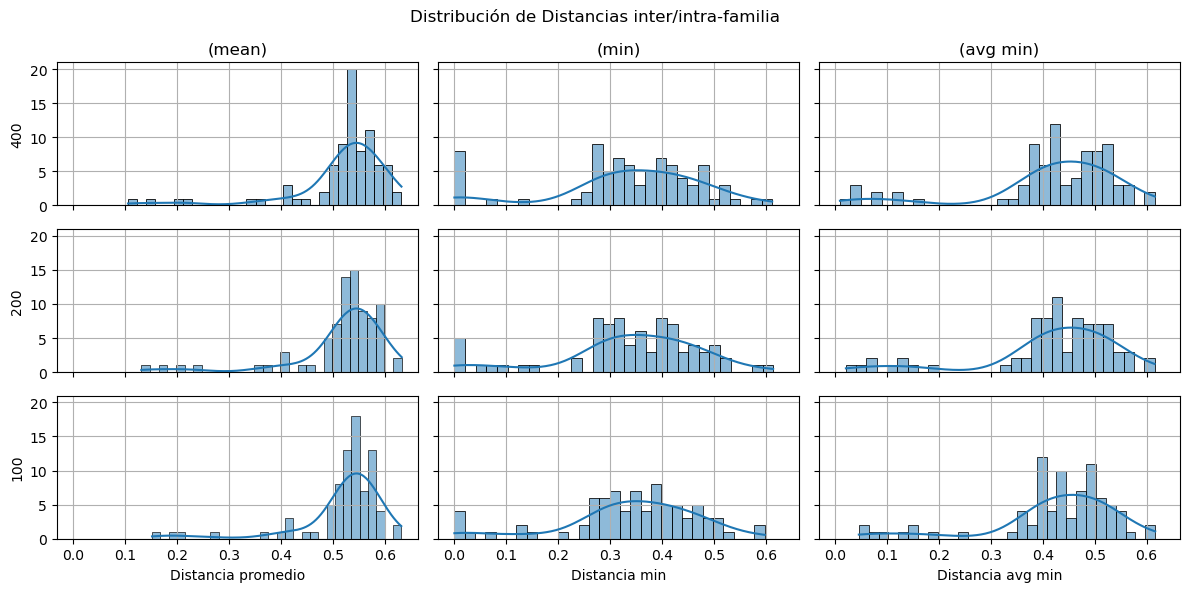

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 3, figsize=(12, 6), sharey=True, sharex=True)

sns.histplot(df_mean_400.values.flatten(), bins=30, kde=True, ax=ax[0, 0])
sns.histplot(df_min_400.values.flatten(), bins=30, kde=True, ax=ax[0, 1])
sns.histplot(df_avgmin_400.values.flatten(), bins=30, kde=True, ax=ax[0, 2])
ax[0, 0].set_title("(mean)")
ax[0, 1].set_title("(min)")
ax[0, 2].set_title("(avg min)")
fig.suptitle("Distribución de Distancias inter/intra-familia")
ax[0, 0].set_xlabel("Distancia promedio")
ax[0, 1].set_xlabel("Distancia min")
ax[0, 2].set_xlabel("Distancia avg min")
ax[0, 0].set_ylabel("400")
ax[0, 0].grid(True)
ax[0, 1].grid(True)
ax[0, 2].grid(True)
sns.histplot(df_mean_200.values.flatten(), bins=30, kde=True, ax=ax[1, 0])
sns.histplot(df_min_200.values.flatten(), bins=30, kde=True, ax=ax[1, 1])
sns.histplot(df_avgmin_200.values.flatten(), bins=30, kde=True, ax=ax[1, 2])

ax[1, 0].set_xlabel("Distancia promedio")
ax[1, 1].set_xlabel("Distancia min")
ax[1, 2].set_xlabel("Distancia avg min")
ax[1, 0].set_ylabel("200")
ax[1, 0].grid(True)
ax[1, 1].grid(True)
ax[1, 2].grid(True)
sns.histplot(df_mean_100.values.flatten(), bins=30, kde=True, ax=ax[2, 0])
sns.histplot(df_min_100.values.flatten(), bins=30, kde=True, ax=ax[2, 1])
sns.histplot(df_avgmin_100.values.flatten(), bins=30, kde=True, ax=ax[2, 2])
ax[2, 0].set_xlabel("Distancia promedio")
ax[2, 1].set_xlabel("Distancia min")
ax[2, 2].set_xlabel("Distancia avg min")
ax[2, 0].set_ylabel("100")
ax[2, 0].grid(True)
ax[2, 1].grid(True)
ax[2, 2].grid(True)
fig.tight_layout()
plt.show()

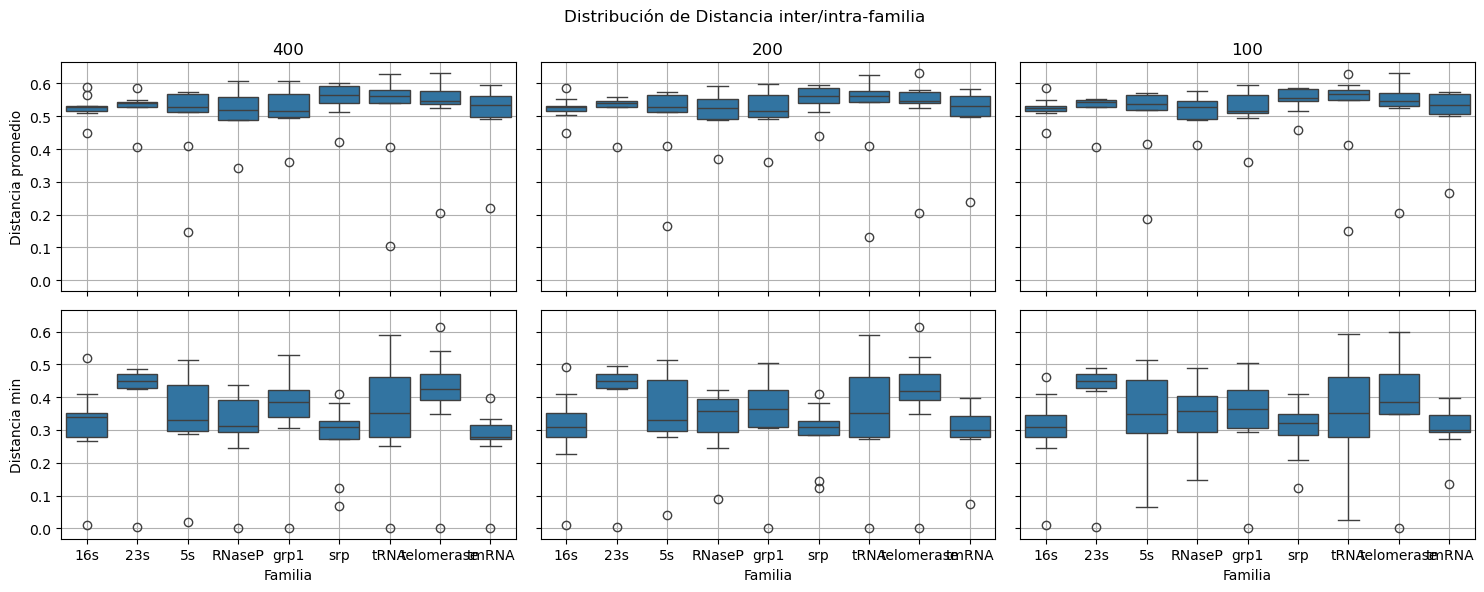

In [11]:





# Quiero trasponer los ejes x e y
fig, ax = plt.subplots(2, 3, figsize=(15, 6), sharey=True, sharex=True)
sns.boxplot(data=df_long_mean_400, x="Familia", y="Distancia", ax=ax[0, 0])
sns.boxplot(data=df_long_min_400, x="Familia", y="Distancia", ax=ax[1, 0]) 
fig.suptitle("Distribución de Distancia inter/intra-familia")
ax[0, 0].set_ylabel("Distancia promedio")
ax[1, 0].set_ylabel("Distancia min")
ax[0, 0].set_title("400")
ax[0, 0].grid(True)
ax[1, 0].grid(True)
sns.boxplot(data=df_long_mean_200, x="Familia", y="Distancia", ax=ax[0, 1])
sns.boxplot(data=df_long_min_200, x="Familia", y="Distancia", ax=ax[1, 1]) 
ax[0, 1].set_title("200")
ax[0, 1].grid(True)
ax[1, 1].grid(True)
sns.boxplot(data=df_long_mean_100, x="Familia", y="Distancia", ax=ax[0, 2])
sns.boxplot(data=df_long_min_100, x="Familia", y="Distancia", ax=ax[1, 2])
ax[0, 2].set_title("100")
ax[0, 2].grid(True)
ax[1, 2].grid(True)
fig.suptitle("Distribución de Distancia inter/intra-familia")

fig.tight_layout()
plt.show()

In [12]:
# # Creamos una copia para evitar modificar el original
# df_no_diag = df_min.copy()

# # Recorremos la diagonal y seteamos esos valores a NaN
# for i in df_no_diag.index:
#     if i in df_no_diag.columns:
#         df_no_diag.loc[i, i] = np.nan

# # Ahora calculamos el promedio por columna sin contar la diagonal (que ahora es NaN)
# column_means = df_no_diag.min()

# # Valores diagonales: Distancia intra-familia
# intra_family = pd.Series(
#     {i: df_min.loc[i, i] for i in df_min.index if i in df_min.columns}
# )

# # Juntamos todo en un DataFrame para análisis o gráfica
# comparison = pd.DataFrame(
#     {
#         "Intra": intra_family,
#         "Inter": column_means,
#     }
# ).sort_values(by="Inter")
# comparison

In [13]:
# Creamos una copia para evitar modificar el original
df_no_diag = df_mean_400.copy()

# Recorremos la diagonal y seteamos esos valores a NaN
for i in df_no_diag.index:
    if i in df_no_diag.columns:
        df_no_diag.loc[i, i] = np.nan

# Ahora calculamos el promedio por columna sin contar la diagonal (que ahora es NaN)
column_means = df_no_diag.mean()

# Valores diagonales: Distancia intra-familia
intra_family = pd.Series(
    {i: df_mean_400.loc[i, i] for i in df_mean_400.index if i in df_mean_400.columns}
)

# Juntamos todo en un DataFrame para análisis o gráfica
comparison_mean = pd.DataFrame(
    {
        "Intra": intra_family,
        "Inter": column_means,
    }
).sort_values(by="Inter")
comparison_mean

,Intra,Inter
5s,0.146450,0.528086
RNaseP,0.341317,0.530797
16s,0.449483,0.535870
tmRNA,0.220808,0.540922
grp1,0.359681,0.542170
23s,0.406968,0.543358
tRNA,0.105131,0.551596
telomerase,0.206336,0.565063
srp,0.421903,0.569357


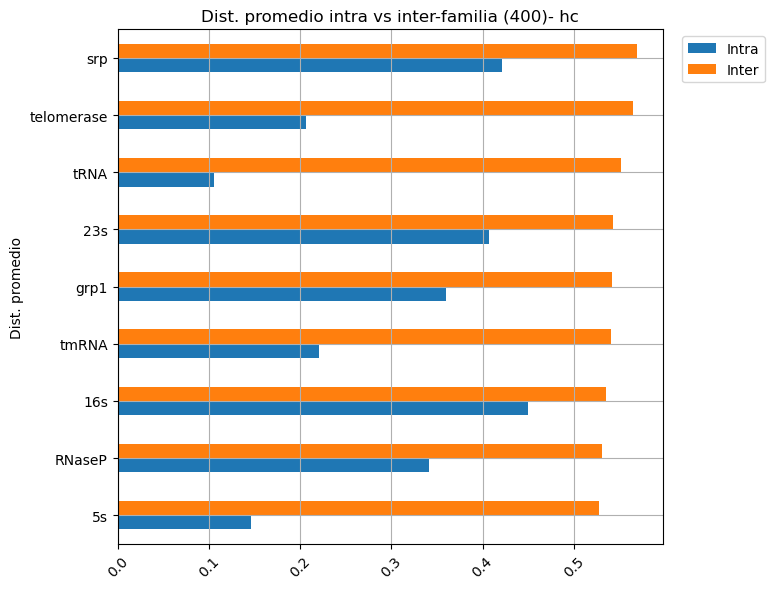

In [14]:
comparison_mean.sort_values('Inter').plot(kind="barh", figsize=(8, 6))
plt.title("Dist. promedio intra vs inter-familia (400)- hc")
plt.ylabel("Dist. promedio")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.2,1))
plt.tight_layout()
plt.show()

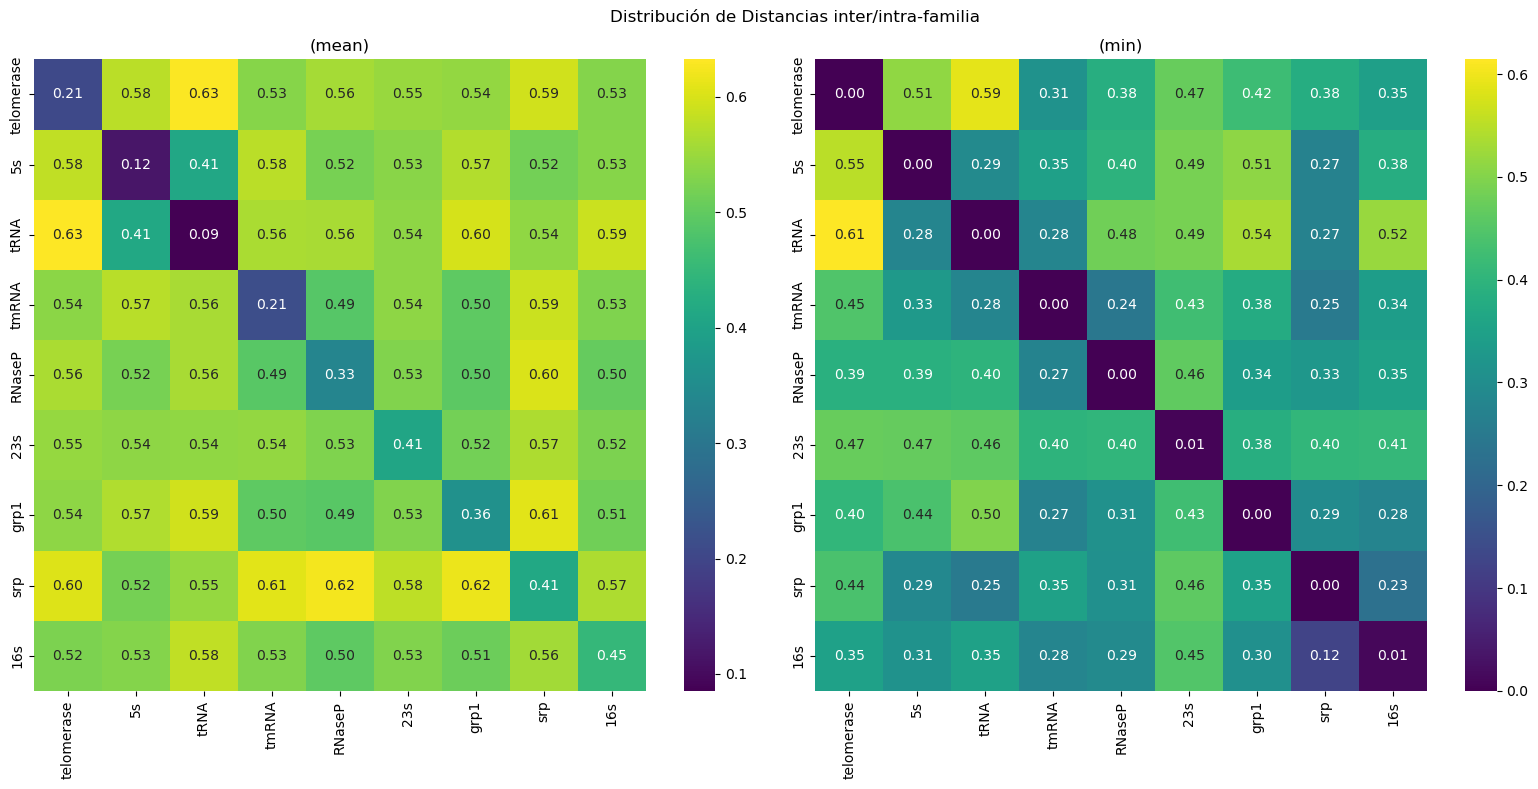

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia")

fig.tight_layout()
plt.show()

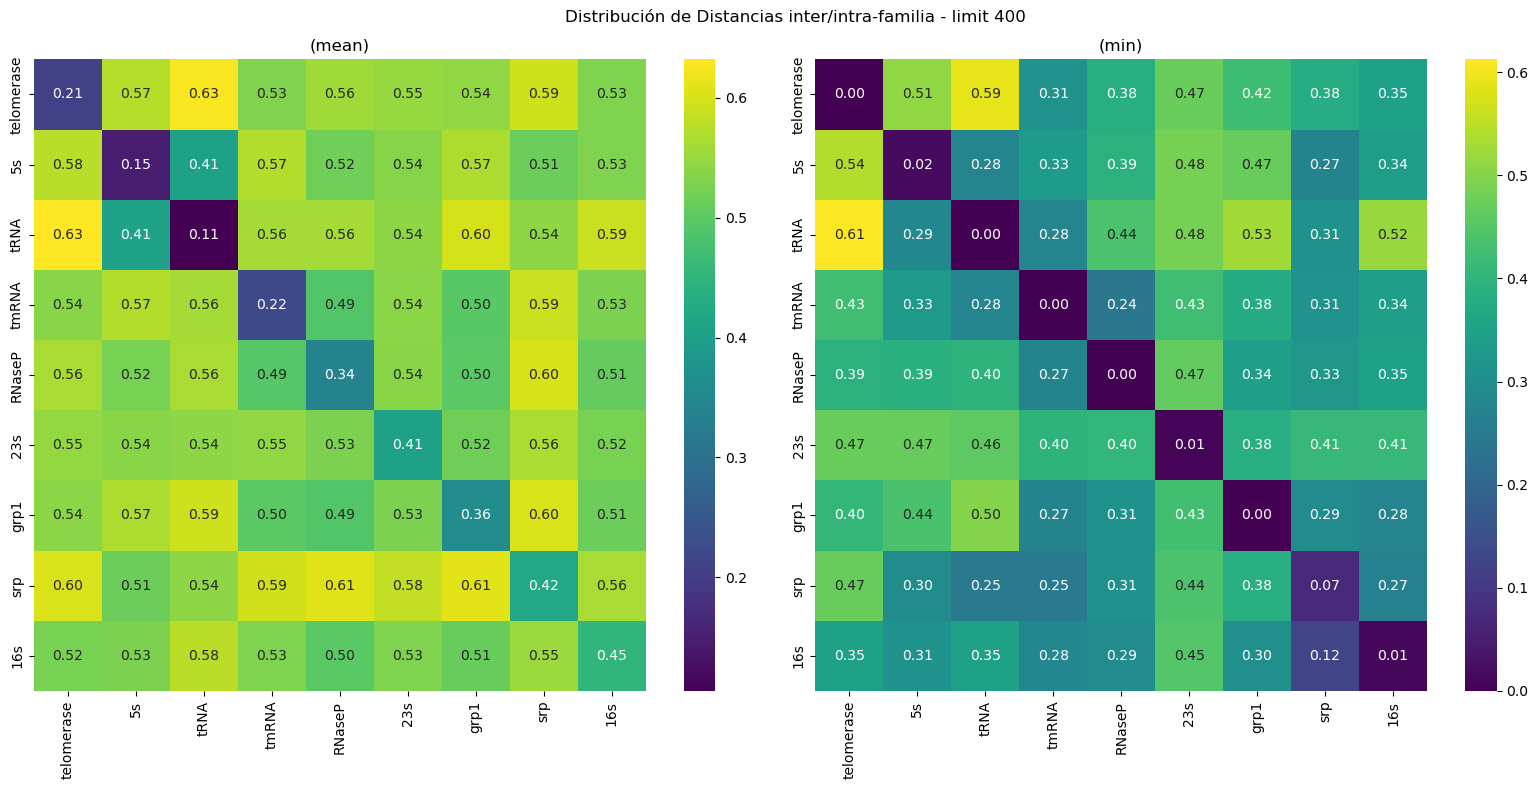

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 400")

fig.tight_layout()
plt.show()

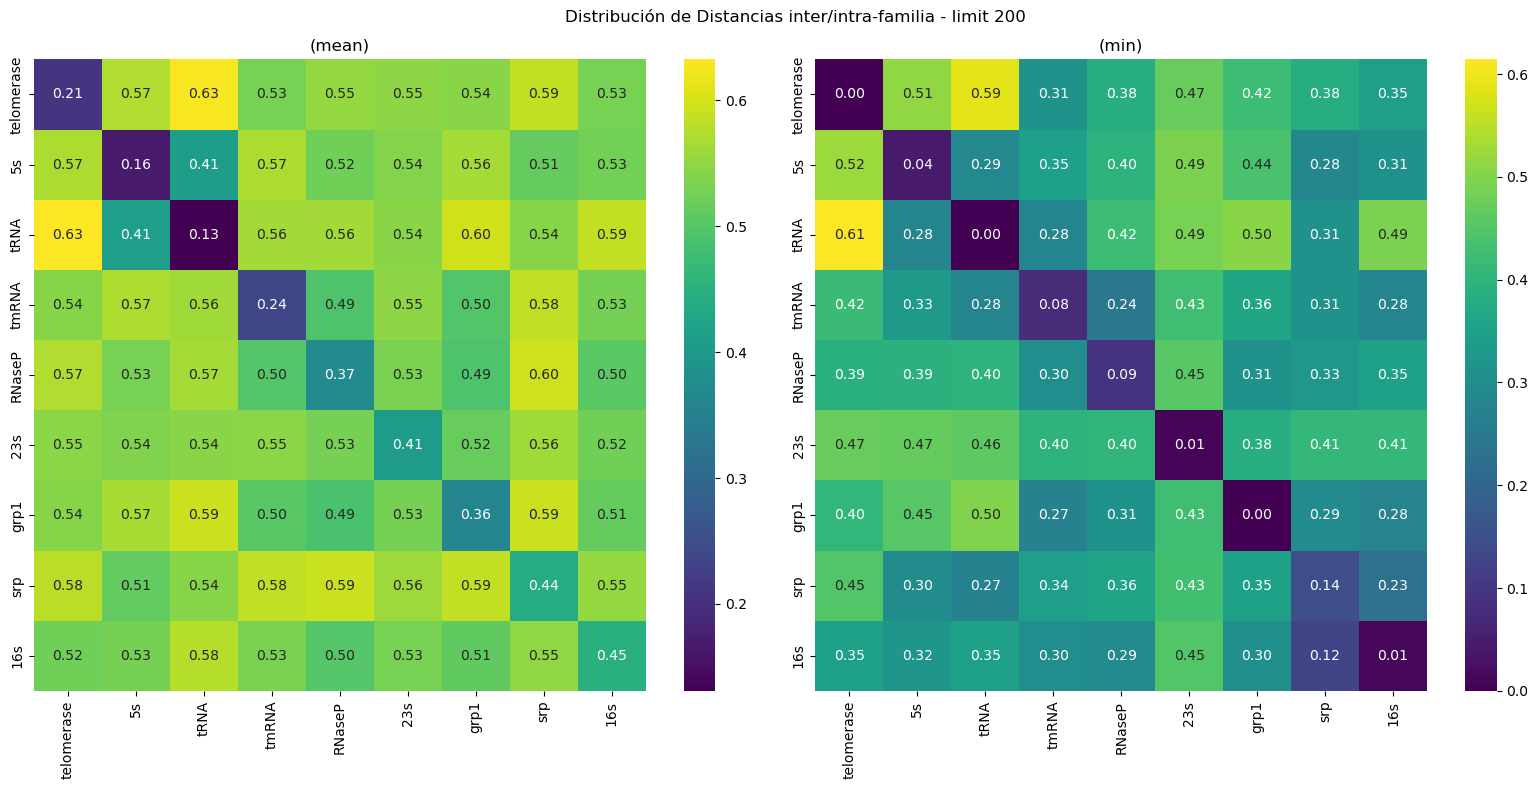

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 200")

fig.tight_layout()
plt.show()

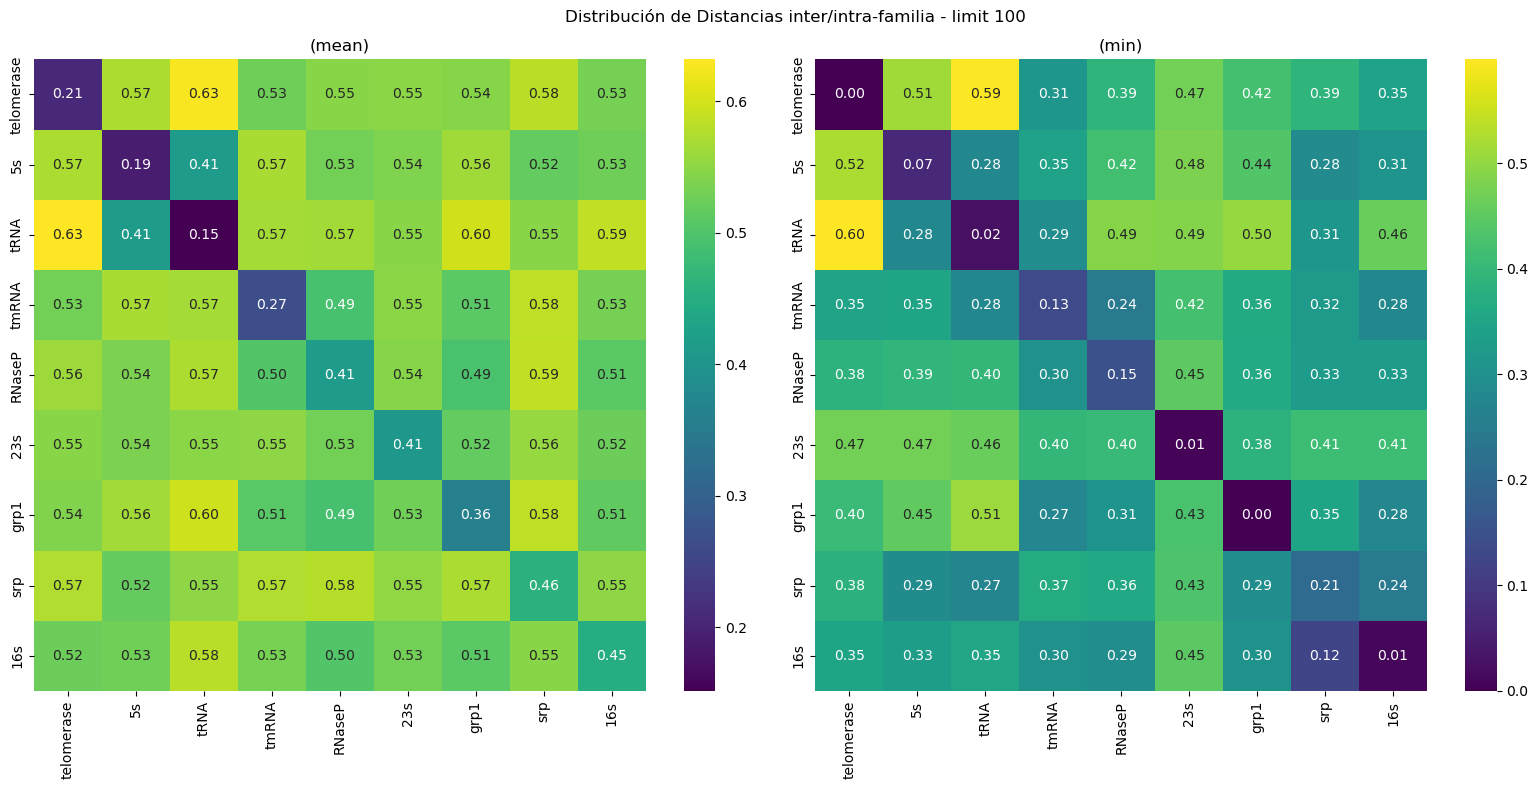

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 100")

fig.tight_layout()
plt.show()

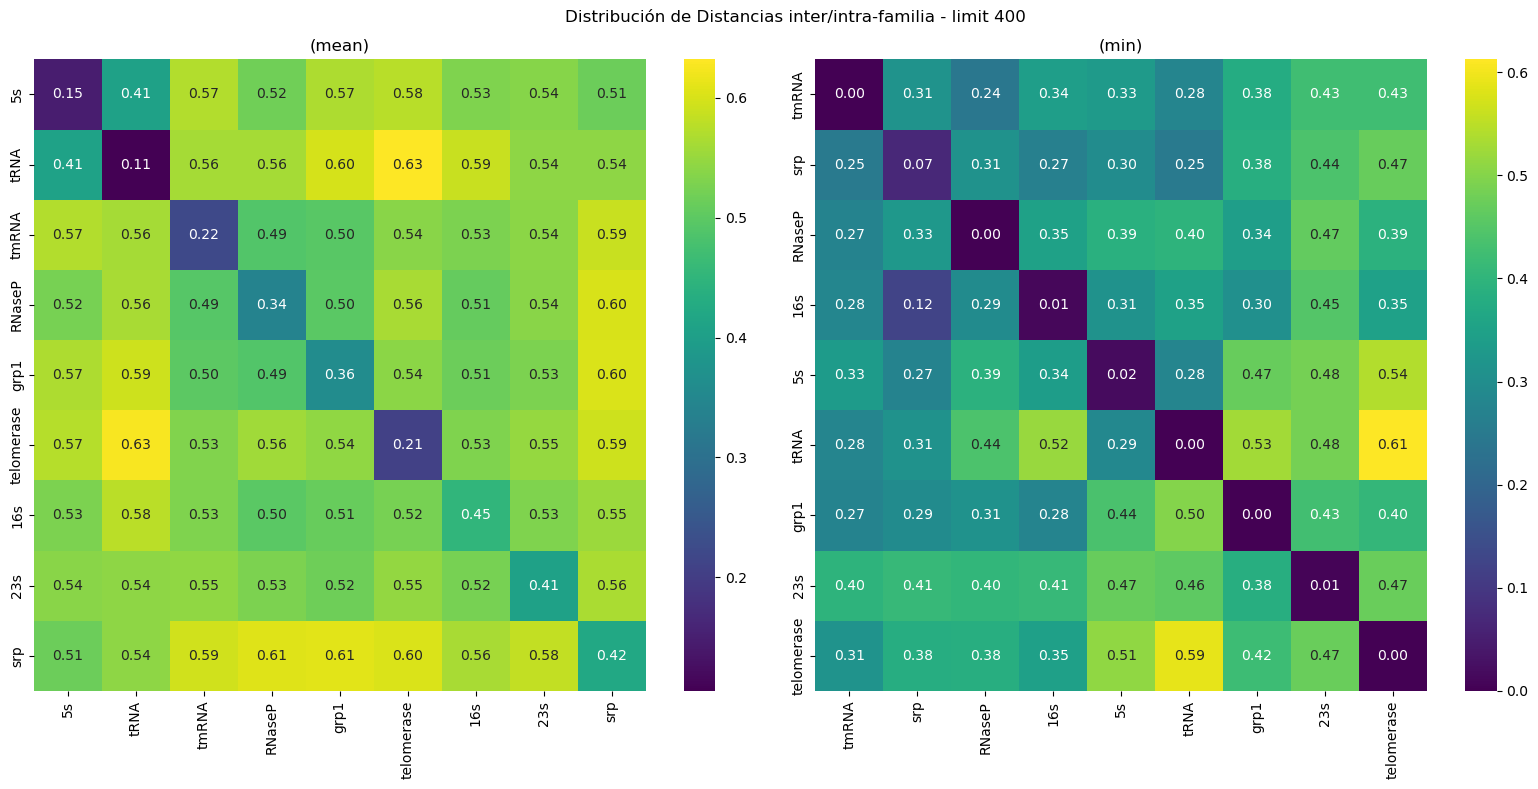

In [19]:
dfff = ru.order_matrix(df_sorted_mean_400)
dfff_sorted_min = ru.order_matrix(df_sorted_min_400)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(dfff, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(dfff_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])


ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 400")

fig.tight_layout()
plt.show()

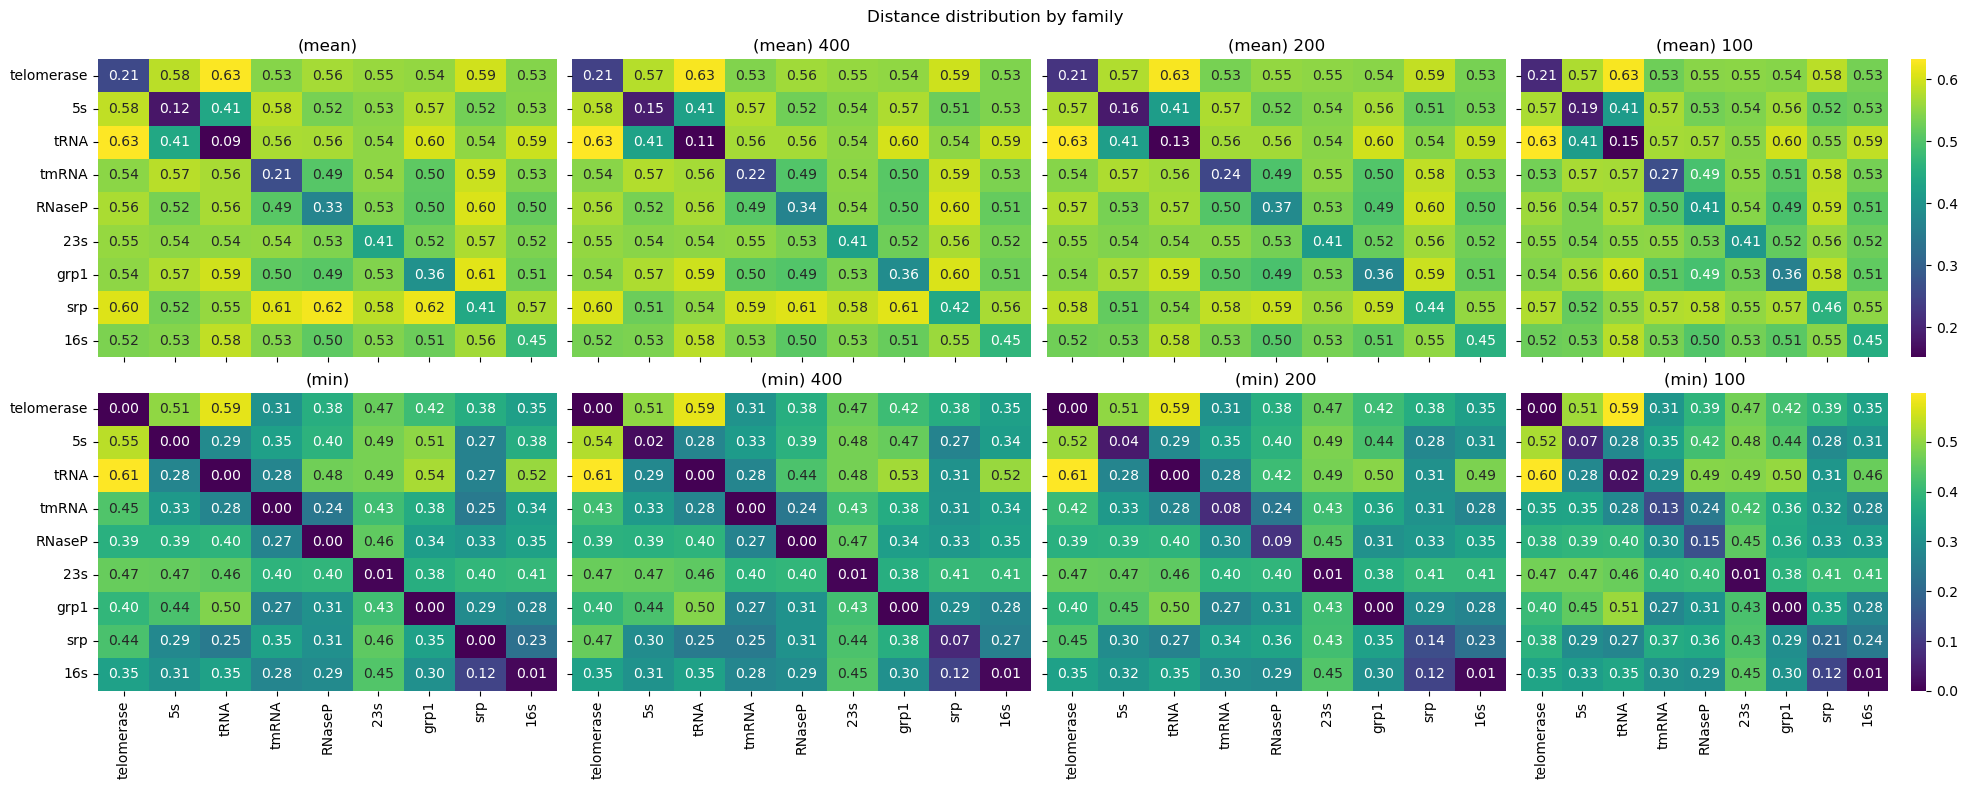

In [20]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,0], cbar=False)
sns.heatmap(df_sorted_mean_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,1], cbar=False)
sns.heatmap(df_sorted_mean_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,2], cbar=False)
sns.heatmap(df_sorted_mean_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,3])
sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,0], cbar=False)
sns.heatmap(df_sorted_min_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,1], cbar=False)
sns.heatmap(df_sorted_min_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,2], cbar=False)
sns.heatmap(df_sorted_min_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,3])
ax[0,0].set_title("(mean)")
ax[0,1].set_title("(mean) 400")
ax[0,2].set_title("(mean) 200")
ax[0,3].set_title("(mean) 100")
ax[1,0].set_title("(min)")
ax[1,1].set_title("(min) 400")
ax[1,2].set_title("(min) 200")
ax[1,3].set_title("(min) 100")
fig.suptitle("Distance distribution by family")
fig.tight_layout()
plt.show()

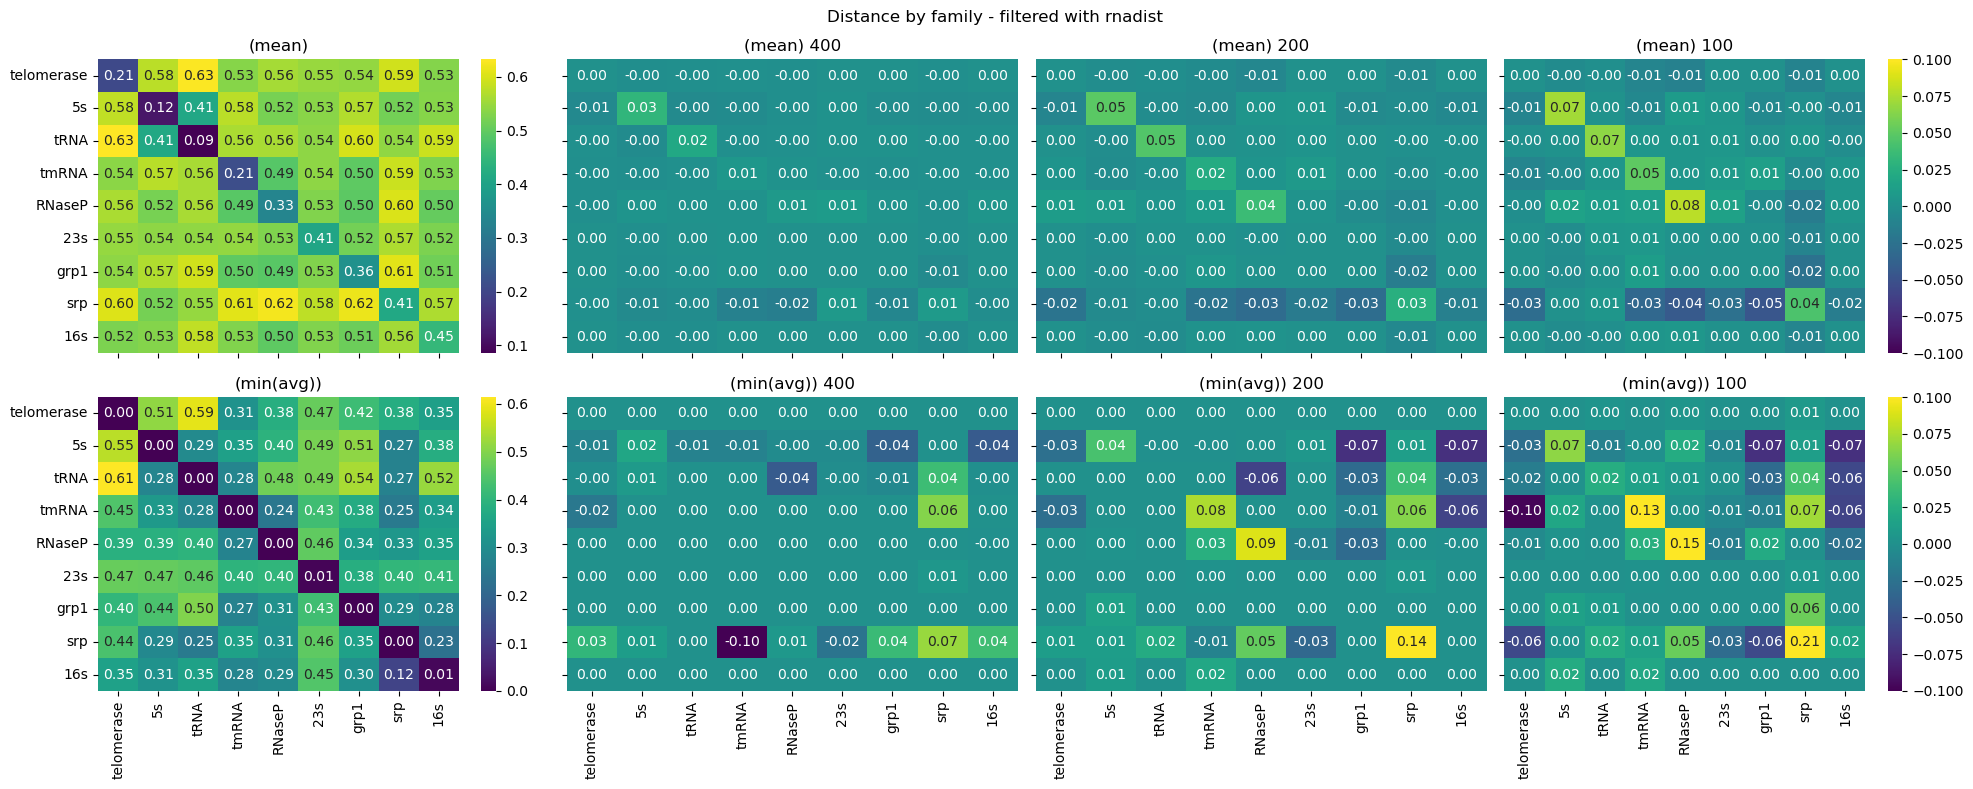

In [21]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,0])

sns.heatmap((df_sorted_mean_400 - df_sorted_mean), annot=True, fmt=".2f", cmap="viridis", ax=ax[0,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_mean_200 - df_sorted_mean), annot=True, fmt=".2f", cmap="viridis", ax=ax[0,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_mean_100 - df_sorted_mean), annot=True, fmt=".2f", cmap="viridis", ax=ax[0,3], vmin=-0.1, vmax=0.1)


sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,0])

sns.heatmap((df_sorted_min_400 - df_sorted_min), annot=True, fmt=".2f", cmap="viridis", ax=ax[1,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_min_200 - df_sorted_min), annot=True, fmt=".2f", cmap="viridis", ax=ax[1,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_min_100 - df_sorted_min), annot=True, fmt=".2f", cmap="viridis", ax=ax[1,3], vmin=-0.1, vmax=0.1)
ax[0,0].set_title("(mean)")
ax[0,1].set_title("(mean) 400")
ax[0,2].set_title("(mean) 200")
ax[0,3].set_title("(mean) 100")
ax[1,0].set_title("(min(avg))")
ax[1,1].set_title("(min(avg)) 400")
ax[1,2].set_title("(min(avg)) 200")
ax[1,3].set_title("(min(avg)) 100")
fig.suptitle("Distance by family - filtered with rnadist")
fig.tight_layout()
plt.show()

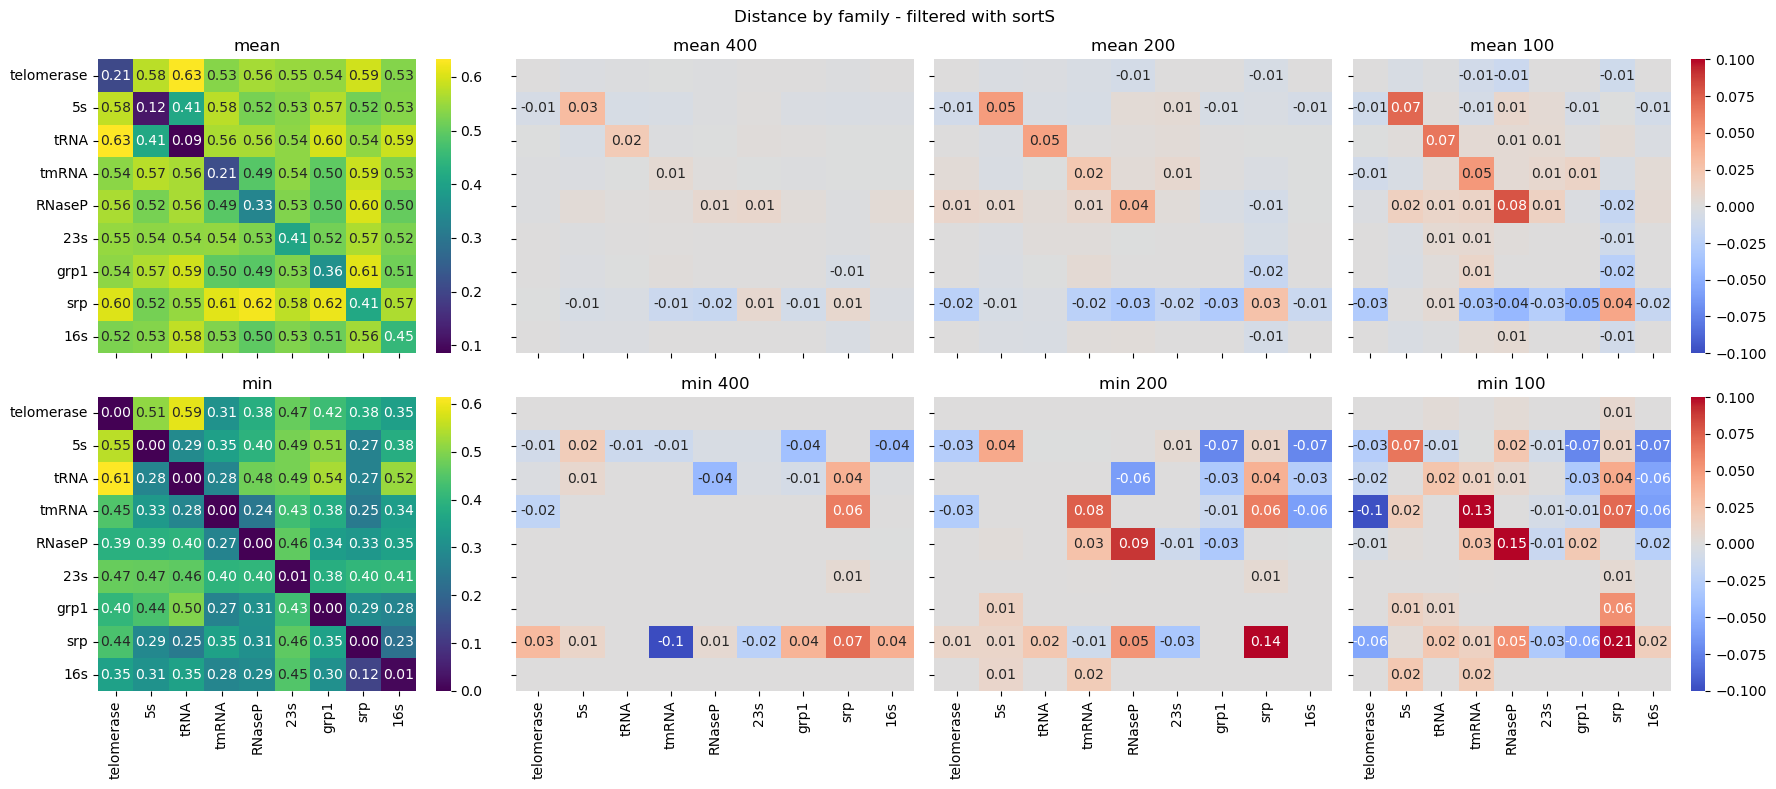

In [25]:
def annot_no_zeros(mat, fmt=".2f"):
    """Devuelve matriz de strings, con '' cuando el valor es 0."""
    return np.where(np.round(mat, 2) == 0, "", mat.astype(float).round(2).astype(str))


fig, ax = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,0])

delta_mean_400 = df_sorted_mean_400 - df_sorted_mean
delta_mean_200 = df_sorted_mean_200 - df_sorted_mean
delta_mean_100 = df_sorted_mean_100 - df_sorted_mean
sns.heatmap(delta_mean_400, annot=  annot_no_zeros(delta_mean_400), fmt="", cmap="coolwarm", ax=ax[0,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_mean_200, annot=  annot_no_zeros(delta_mean_200), fmt="", cmap="coolwarm", ax=ax[0,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_mean_100, annot=  annot_no_zeros(delta_mean_100), fmt="", cmap="coolwarm", ax=ax[0,3], vmin=-0.1, vmax=0.1)


sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,0])

delta_min_400 = df_sorted_min_400 - df_sorted_min
delta_min_200 = df_sorted_min_200 - df_sorted_min
delta_min_100 = df_sorted_min_100 - df_sorted_min
sns.heatmap(delta_min_400, annot= annot_no_zeros(delta_min_400), fmt="", cmap="coolwarm", ax=ax[1,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_min_200, annot= annot_no_zeros(delta_min_200), fmt="", cmap="coolwarm", ax=ax[1,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_min_100, annot= annot_no_zeros(delta_min_100), fmt="", cmap="coolwarm", ax=ax[1,3], vmin=-0.1, vmax=0.1)


ax[0,0].set_title("mean")
ax[0,1].set_title("mean 400")
ax[0,2].set_title("mean 200")
ax[0,3].set_title("mean 100")
ax[1,0].set_title("min")
ax[1,1].set_title("min 400")
ax[1,2].set_title("min 200")
ax[1,3].set_title("min 100")
fig.suptitle("Distance by family - filtered with sortS")
fig.tight_layout()
plt.show()